In [1]:
import pandas as pd

In [6]:
pure_cascades=pd.read_parquet('Trigger_process/Cascade/merged/1/')

In [7]:
noisy_cascades=pd.read_parquet('Trigger_process/Cascade/merged/1_20_21/')

In [13]:
data_filter=noisy_cascades['energy']<10**4.5

In [22]:
filtered_noise=noisy_cascades[data_filter][['Mod Count CL: 7','energy']]
filtered_cascade=pure_cascades[data_filter][['Mod Count CL: 7','energy']]

In [24]:
recall=filtered_cascade['Mod Count CL: 7']/filtered_noise['Mod Count CL: 7']

In [25]:
import matplotlib.pyplot as plt

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def plot_recall_vs_energy(path, use_log=True):
    # Get parquet file
    files = os.listdir(path)
    files.sort()
    file = [f for f in files if '_20_21' in f][0]
    parquet_path = os.path.join(path, file)
    parquet_path = [os.path.join(parquet_path, f) for f in os.listdir(parquet_path) if f.endswith('.parquet')][0]
    
    # Load data
    df = pd.read_parquet(parquet_path).drop_duplicates()
    
    # Apply energy filter based on path
    if 'Cascade' in path:
        energy_filter = df['energy'] < 10**3.8
        title='Recall as a function of Energy (Cascade)'
        
    elif "Track" in path:
        energy_filter = df['energy'] < 10**4.8
        title='Recall as a function of Energy (Track)'
    else:
        print('Maybe error: path should contain "Cascade" or "Track"')
        return
    
    # Filter dataframe
    df = df[energy_filter]
    
    # Process data
    energy = df['energy']
    energy_log = np.log10(energy) if use_log else energy
    bins = np.histogram_bin_edges(energy_log, bins=25)
    
    # Get CL=7 column
    hit_col = [c for c in df.columns if "Hit" in c][7]
    e0 = df[df[hit_col] != 0]['energy']
    e0_log = np.log10(e0) if use_log else e0
    
    # Calculate recall
    hist_total, _ = np.histogram(energy_log, bins=bins)
    hist_e0, _ = np.histogram(e0_log, bins=bins)
    mask = hist_total > 0
    recall = hist_e0[mask] / hist_total[mask]
    bin_centers = ((bins[:-1] + bins[1:]) / 2)[mask]
    
    # Linear regression
    model = LinearRegression().fit(bin_centers.reshape(-1, 1), recall)
    trend_y = model.predict(bin_centers.reshape(-1, 1))
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.step(bin_centers, recall, where='mid', label='CL=7', color='blue')
    plt.plot(bin_centers, trend_y, '--', color='red', label='Trend CL=7')
    plt.title(title)
    plt.xlabel('Energy [GeV]')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid()
    plt.show()

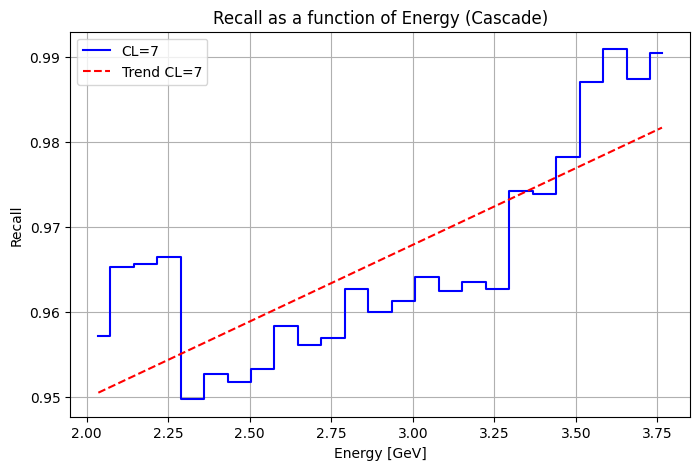

In [39]:
plot_recall_vs_energy("Trigger_process/Cascade/merged/")

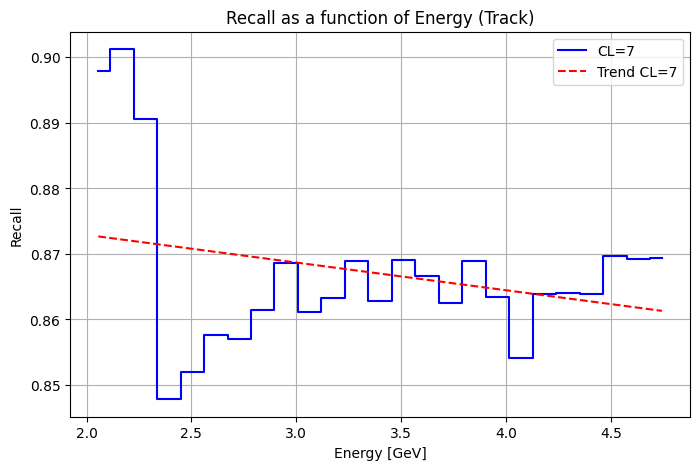

In [40]:
plot_recall_vs_energy("Trigger_process/Track/merged/")